Test functions in the fuori_area_clustering_functions script (analysis in fuori_area.ipynb).

In [2]:
from fuori_area_clustering_functions import *

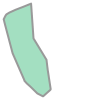

In [17]:
# alpha shape to define the area within which e-scooters can move
get_area_limite()

In [4]:
df_outside_area = get_trips_outside_area()

In [5]:
traj_df = trips_trajectories(df_outside_area)

In [6]:
traj_df

,unique_id,route
0,00000023-0000-1000-95b3-5b7d6a617b60_2021-06-24,"[[11.111598, 46.041653], [11.118816, 46.068243]]"
1,00000047-0000-1000-a317-5b7d6a617b60_2022-01-16,"[[11.112671, 46.05746], [11.107499, 46.037448]]"
2,0000004f-0000-1000-87af-5b7d6a617b60_2021-08-19,"[[11.112823, 46.04158], [11.130582, 46.05629]]"
3,00000092-0000-1000-a4f2-5b7d6a617b60_2021-11-18,"[[11.122504, 46.050957], [11.108495, 46.037913]]"
4,00000097-0000-1000-a277-5b7d6a617b60_2022-02-17,"[[11.112345, 46.043163], [11.127957, 46.067184]]"
...,...,...
250,e69401d6fe31_2021-05-05,"[[11.151947, 46.080051], [11.151916, 46.080072..."
251,e815c6d8b1b1_2021-08-28,"[[11.119657, 46.063973], [11.119654, 46.063974..."
252,e9e26b748e3b_2021-09-06,"[[11.133507, 46.046881], [11.133539, 46.046847..."
253,f627db8fe2d5_2021-08-31,"[[11.131177, 46.048902], [11.131196, 46.0489],..."


In [12]:
similarity_matrix = pd.DataFrame(compute_distance_matrix(traj_df.route.to_list(), method='Frechet'), columns=traj_df.unique_id.to_list(), index=traj_df.unique_id.to_list())

# or

similarity_matrix = distance_matrix_trajectory_df(traj_df, method='Frechet')

In [15]:
# apply DBSCAN for trajectories clustering 
# TO MANIPULATE HOW MUCH SIMILARITY BETWEEN TRAJECTORIES MUST BE, CHANGE THE EPS PARAMETER
lst_cluster_labels = clustering_trajectories(similarity_matrix, eps=0.01)

In [ ]:
# folium map (trajectories are grouped by cluster; clusters to visualize can be selected in the drop down menu on the upper right)
viz_trajectories_clusters(traj_df, similarity_matrix, eps=0.01)